In [2]:
#Ejercicio 1.1

def primos_1_a_20():
    print(2, 3, 5, 7, 11, 13, 17, 19)

primos_1_a_20()

2 3 5 7 11 13 17 19


In [3]:
#Ejercicio 1.2

def primos_hasta_n(n: int) -> list[int]:
    primos = []
    for i in range(n + 1):
        if es_primo(i):
            primos.append(i)
    return primos


def es_primo(n: int) -> bool:
    if n < 2:
        return False
    for i in range(2,n):
        if n % i == 0:
            return False
    return True

primos_hasta_n(31)

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31]

#Ejercicio 1.3
La función primos_hasta_n toma un entero n y devuelve una lista de enteros.
Primero arma la lista vacía, y con un for recorremos todos los numeros desde 0
hasta n + 1 ya que range(inicio, fin) no incluye al fin.
Usando la funcion auxiliar es_primo, nos fijamos si i es primo y en caso de serlo,
se añade a la lista de primos.
Al final, se devuelve dicha lista.

La función es_primo toma un entero n y devuelve un booleano.
Primero vemos si n es menor que 2, si lo es, devuelve False.
Luego, usando for, vemos si algún natural mayor que 1 y menor que n lo divide a n,
si alguno lo divide, devuelve False.
En caso de no ser divisible por ninguno, devuelve True

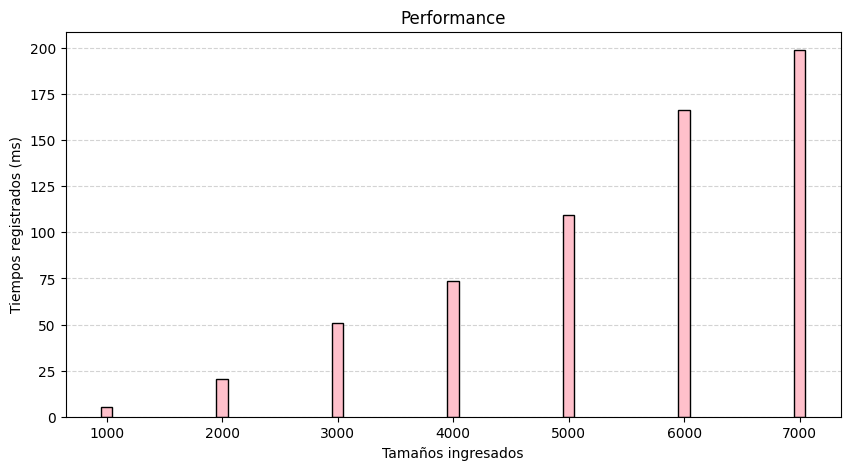

In [11]:
#Ejercicio 1.5
import time
import matplotlib.pyplot as plt

tamaños = [1000, 2000, 3000, 4000, 5000, 6000, 7000]
tiempos = []
for n in tamaños:
    inicio = time.perf_counter()
    primos_hasta_n(n)
    fin = time.perf_counter()
    tiempos.append((fin - inicio) * 1000)

plt.figure(figsize=(10,5))
plt.bar(tamaños, tiempos,  color="pink", width=100, edgecolor="black", zorder=2)
plt.grid(axis="y", linestyle="--", color="lightgray", zorder=1)
plt.xlabel("Tamaños ingresados")
plt.ylabel("Tiempos registrados (ms)")
plt.title("Performance")
plt.show()

In [5]:
#Ejercicio 2
import random
def genera_password() -> str:
    pre = ""
    nombre = input("Ingrese su nombre:")
    dni = input("Ingrese su DNI:")
    fecha = input("Ingrese su fecha de nacimiento (DDMMAAAA):")
    for i in range(3):
        pre += random.choice(nombre)
    for i in range(3):
        pre += random.choice(fecha)
    for i in range(2):
        pre += random.choice(dni)
    res = list(pre)
    random.shuffle(res)
    contador = 0
    while contador == 0:
        rep = 0
        for i in range(7):
            sub = str(res[i]) + str(res[i + 1])
            if sub in nombre or sub in dni or sub in fecha:
                rep += 1
        if rep > 0:
            random.shuffle(res)
        else:
            contador = 1
    password = "".join(res)
    return password

genera_password()

's31404ls'

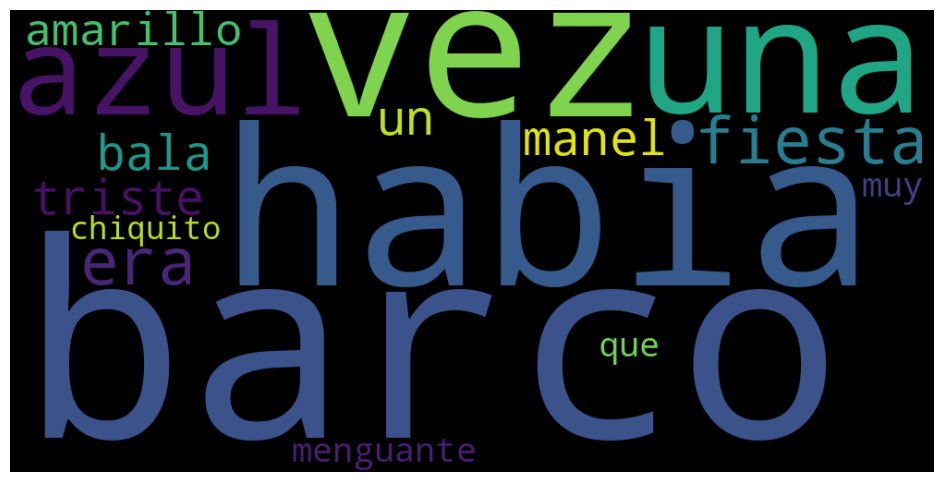

In [7]:
#Ejercicio 3
from wordcloud import WordCloud

file = open("/home/pizza/Escritorio/Bioinformática/TP 0/palabras.txt", "r")
archivo = file.readlines()
file.close()

def forma_palabras(texto: list[str]) -> list[str]:
    palabras = []
    for renglon in texto:
        palabra = ""
        for caracter in renglon:
            if caracter != " " and caracter != "\n" and caracter != ",":
                palabra += caracter.lower()
            else:
                if palabra != "":
                    palabras.append(palabra)
                palabra = ""
    return palabras

def aparicion_una_palabra(palabra: str) -> int:
    contador = 0
    palabras = forma_palabras(archivo)
    for i in palabras:
        if palabra == i:
            contador += 1
    return contador

def apariciones_por_palabra(texto: str) -> dict[str, int]:
    palabras = forma_palabras(texto)
    cantidad = {}
    for palabra in palabras:
        if palabra not in cantidad:
            cantidad[palabra] = 0
        cantidad[palabra] += 1
    return cantidad

nube = WordCloud(
    width=1000,
    height=500,
    background_color="black",
    colormap= "viridis",
    prefer_horizontal=1.0,
    ).generate_from_frequencies(apariciones_por_palabra(archivo))

plt.figure(figsize=(12,6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.show()